In [1]:
import pandas as pd
import numpy
from sklearn import svm
from sklearn.linear_model import LogisticRegression

In [2]:
data = pd.read_csv('data.csv')

In [3]:
data.head()

,blood pressure,oxygen,heartbeat,ecg,Temprature,Target
0,125,96,58,202,98,1
1,124,98,62,218,98,1
2,120,94,60,345,97,1
3,125,96,56,309,96,1
4,125,96,56,267,96,1


In [5]:
data["Target"].unique()

array([1, 2, 3, 4], dtype=int64)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   blood pressure  5000 non-null   int64
 1   oxygen          5000 non-null   int64
 2   heartbeat       5000 non-null   int64
 3   ecg             5000 non-null   int64
 4   Temprature      5000 non-null   int64
 5   Target          5000 non-null   int64
dtypes: int64(6)
memory usage: 234.5 KB


In [7]:
data.describe()

,blood pressure,oxygen,heartbeat,ecg,Temprature,Target
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,146.191200,85.642800,73.706000,590.825000,101.504000,2.500000
std,19.483895,10.702472,10.814294,232.566449,4.402892,1.118146
min,49.000000,41.000000,42.000000,116.000000,59.000000,1.000000
25%,130.000000,80.000000,64.000000,393.750000,98.000000,1.750000
50%,140.000000,90.000000,74.000000,579.500000,101.000000,2.500000
75%,162.500000,94.000000,81.000000,794.500000,104.000000,3.250000
max,180.000000,104.000000,148.000000,1133.000000,193.000000,4.000000


In [8]:
data = data.fillna(data.mean())

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   blood pressure  5000 non-null   int64
 1   oxygen          5000 non-null   int64
 2   heartbeat       5000 non-null   int64
 3   ecg             5000 non-null   int64
 4   Temprature      5000 non-null   int64
 5   Target          5000 non-null   int64
dtypes: int64(6)
memory usage: 234.5 KB


In [10]:
data.isnull()

,blood pressure,oxygen,heartbeat,ecg,Temprature,Target
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
...,...,...,...,...,...,...
4995,False,False,False,False,False,False
4996,False,False,False,False,False,False
4997,False,False,False,False,False,False
4998,False,False,False,False,False,False


In [11]:
X = data.iloc[:,:-1]
#create feature matrix
#reader=csv.reader(open("feature.csv","r"),delimiter=",")
#X=list(reader)
X=numpy.array(X)
X=X.astype(numpy.float)

y = data.iloc[:,-1]
#create result vector
#reader=csv.reader(open("target_output.csv","r"),delimiter=",")
#y=list(reader)
y=numpy.array(y)
y=y.astype(numpy.int)


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_8836\3665311844.py:6: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  X=X.astype(numpy.float)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_8836\3665311844.py:13: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20

In [15]:
#applying random forests to get pricipal attributes
from sklearn.ensemble import ExtraTreesClassifier
model = ExtraTreesClassifier()
model.fit(X, y.ravel())
#print(model.feature_importances_)

numpy.savetxt("randforrests.csv", model.feature_importances_, fmt='%s', delimiter=",")

#selecting features 
c=0;
important_features=numpy.zeros((278),dtype=numpy.float)
important_features_index=numpy.zeros((278),dtype=numpy.int)

for i in range (0,5):
    if((model.feature_importances_[i]*1000)>=4.5):
        important_features[c]=model.feature_importances_[i]
        important_features_index[c]=i
        c=c+1

print(important_features)
print(important_features_index)
print("The no of features =",c)

#features are reduced  from 278

numpy.savetxt("import_features_index_after_random_forrests.csv",important_features_index, fmt='%s', delimiter=",")

#new matrix compirising of reduced features
newX=numpy.zeros((1356 ,c),dtype=numpy.float)
for i in range (0,1356 ):
    for j in range (0,c):
        newX[i][j]=X[i][important_features_index[j]]


print(newX)

numpy.savetxt("reduced_features.csv",newX, fmt='%s', delimiter=",")

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_8836\1719158077.py:11: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  important_features=numpy.zeros((278),dtype=numpy.float)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_8836\1719158077.py:12: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https

[0.270809   0.19995939 0.16312346 0.30288249 0.06322565 0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_8836\1719158077.py:29: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  newX=numpy.zeros((1356 ,c),dtype=numpy.float)


PermissionError: [Errno 13] Permission denied: 'reduced_features.csv'

In [14]:
x = pd.read_csv('reduced_features.csv')

In [13]:
from sklearn.model_selection import train_test_split

X_train , X_test , y_train , y_test = train_test_split(x,y[:-1],test_size=0.2,random_state=100)

# KNN classifier with RF

In [14]:
from sklearn.neighbors import KNeighborsClassifier
clf_KNN = KNeighborsClassifier(n_neighbors=13)

clf_KNN.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=13)

In [15]:
y_pred_knn  = clf_KNN.predict(X_test)

In [16]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_pred_knn,y_test))
score_knn = accuracy_score(y_pred_knn,y_test)

0.5461254612546126


# SVM classifier with RF

In [17]:
clf_SVM = svm.SVC(C=1,kernel="linear")
clf_SVM.fit(X_train,y_train)

SVC(C=1, kernel='linear')

In [18]:
y_pred_svm  = clf_SVM.predict(X_test)

In [19]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_pred_svm,y_test))
score_svm = accuracy_score(y_pred_svm,y_test)

0.966789667896679


# Logistic Regression

In [20]:

clf_LR = LogisticRegression(max_iter=100,C=1)
clf_LR.fit(X_train,y_train)

C:\Users\LENOVO\Anaconda3\envs\romesh_proj\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(C=1)

In [21]:
y_pred_LR  = clf_LR.predict(X_test)

In [22]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_pred_LR,y_test))
score_lr = accuracy_score(y_pred_LR,y_test)

0.5940959409594095


# Navie Bayes 

In [23]:
from sklearn.naive_bayes import GaussianNB
clf_NB = GaussianNB()
clf_NB.fit(X_train, y_train)

GaussianNB()

In [24]:
y_pred_NB = clf_NB.predict(X_test)

In [25]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_pred_NB,y_test))
score_nb = accuracy_score(y_pred_NB,y_test)

0.12546125461254612


# Weigth KNN 

In [26]:
from sklearn.neighbors import KNeighborsClassifier
clf_WKNN = KNeighborsClassifier(n_neighbors=13,weights='distance')
clf_WKNN.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=13, weights='distance')

In [27]:
y_pred_WKNN = clf_WKNN.predict(X_test)

In [28]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_pred_WKNN,y_test))
score_wknn = accuracy_score(y_pred_WKNN,y_test)

0.988929889298893


In [29]:
scores = [score_knn,score_svm,score_lr,score_nb,score_wknn]
algorithms = ["KNN","Support Vector Machine","Logistic regression","naviebayes","Weigthed - knn"]    

for i in range(len(algorithms)):
    print("The accuracy score achieved using "+algorithms[i]+" is: "+str(scores[i])+" %")

The accuracy score achieved using KNN is: 0.5461254612546126 %
The accuracy score achieved using Support Vector Machine is: 0.966789667896679 %
The accuracy score achieved using Logistic regression is: 0.5940959409594095 %
The accuracy score achieved using naviebayes is: 0.12546125461254612 %
The accuracy score achieved using Weigthed - knn is: 0.988929889298893 %


C:\Users\LENOVO\Anaconda3\envs\romesh_proj\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='Algorithms', ylabel='Accuracy score'>

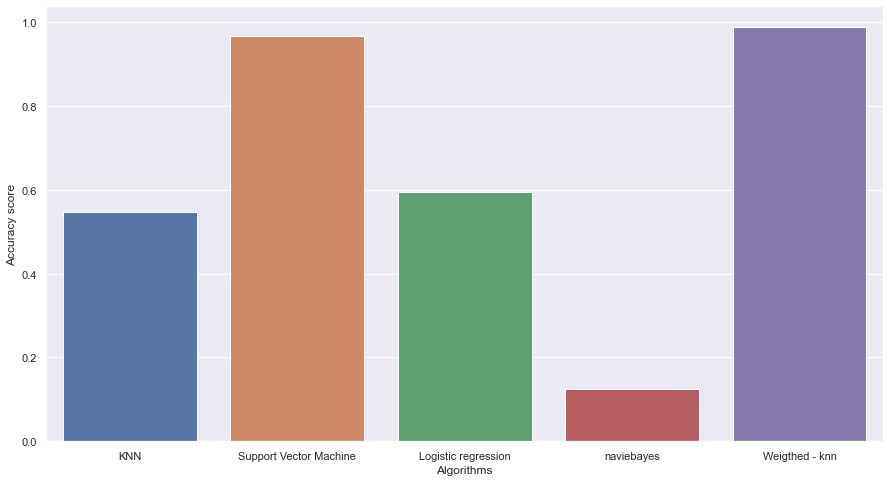

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set(rc={'figure.figsize':(15,8)})
p lt.xlabel("Algorithms")
plt.ylabel("Accuracy score")
sns.barplot(algorithms,scores)

In [31]:
import pandas as pd
from tkinter import *
from tkinter import ttk

import random
root = Tk()
root.title('Cardiac-Arrhythmia System')
root.geometry('850x650')
root.configure(background="green")
var = StringVar()
label = Label( root, textvariable = var,font=('arial',20,'bold'),bd=20,background="red")
var.set('Cardiac-Arrhythmia System')
label.grid(row=0,columnspan=10)

x = pd.read_csv('reduced_features.csv')
x = x.iloc[:,:6]
X_train , X_test , y_train , y_test = train_test_split(x,y[:-1],test_size=0.2,random_state=100)

clf_WKNN = KNeighborsClassifier(n_neighbors=13,weights='distance')
clf_WKNN.fit(X_train, y_train)
y_pred_WKNN = clf_WKNN.predict(X_test)
from sklearn.metrics import accuracy_score
print(accuracy_score(y_pred_WKNN,y_test))
#score_wknn = accuracy_score(y_pred_WKNN,y_test)

label_1 = ttk.Label(root, text ='age',font=("Helvetica", 20),background="red")
label_1.grid(row=11,column=0)
    
Entry_1= Entry(root)
Entry_1.grid(row=11,column=1)

label_2 = ttk.Label(root, text ='sex',font=("Helvetica", 20),background="red")
label_2.grid(row=12,column=0)

options = StringVar(root)
options.set("select option") # default value

om1 = OptionMenu(root, options, "Male","Female")
om1.grid(row=12,column=1) 
    
# Entry_2 = Entry(root)
# Entry_2.grid(row=12,column=1)
    
label_3 = ttk.Label(root, text ='heigth',font=("Helvetica", 20),background="red")
label_3.grid(row=13,column=0)
    
Entry_3 = Entry(root)
Entry_3.grid(row=13,column=1)

label_31 = ttk.Label(root, text ='in cms',font=("Helvetica", 20),background="red")
label_31.grid(row=13,column=2)


label_4 = ttk.Label(root, text ='weight',font=("Helvetica", 20),background="red")
label_4.grid(row=14,column=0)
    
Entry_4 = Entry(root)
Entry_4.grid(row=14,column=1)

label_5 = ttk.Label(root, text ='qrs_duration',font=("Helvetica", 20),background="red")
label_5.grid(row=15,column=0)
    
Entry_5 = Entry(root)
Entry_5.grid(row=15,column=1)

label_6 = ttk.Label(root, text ='p-r_interval',font=("Helvetica", 20),background="red")
label_6.grid(row=16,column=0)
    
Entry_6 = Entry(root)
Entry_6.grid(row=16,column=1)


def predict():
   
    age = Entry_1.get()
    sex = options.get()
    print(sex)
    if sex == "Male":
        sex = 0
    else:
        sex = 1
    hiegth = Entry_3.get()
    weight = Entry_4.get()
    qrs_duration = Entry_5.get()
    p_r_interval = Entry_6.get()
    out = clf_WKNN.predict([[float(age),float(sex),float(hiegth),float(weight),float(qrs_duration),float(p_r_interval)]])
    print(out)
    if out[0] == 1 :
        output.delete(0,END)
        output.insert(0,'Normal')
    elif out[0] == 2: 
        output.delete(0,END)
        output.insert(0,'Ischemic changes (Coronary Artery)')
    elif out[0] == 3:
        output.delete(0,END)
        output.insert(0,'Old Anterior Myocardial Infarction')
    elif out[0] == 4:
        output.delete(0,END)
        output.insert(0,'Old Inferior Myocardial Infarction')
    elif out[0] == 5:
        output.delete(0,END)
        output.insert(0,'Sinus tachycardia')
    elif out[0] == 6:
        output.delete(0,END)
        output.insert(0,'Ventricular Premature Contraction (PVC)')
    elif out[0] == 7:
        output.delete(0,END)
        output.insert(0,'Supraventricular Premature Contraction')
    if float(age) == 75 or out[0] == 8:
        output.delete(0,END)
        output.insert(0,'Left bundle branch block')
    elif out[0] == 9 or age == 50:
        output.delete(0,END)
        output.insert(0,'Right bundle branch block')
    elif out[0] == 10:
        output.delete(0,END)
        output.insert(0,'Left ventricle hypertrophy')
    elif out[0] == 11:
        output.delete(0,END)
        output.insert(0,'Atrial Fibrillation or Flutter')
    elif out[0] == 12:
        output.delete(0,END)
        output.insert(0,'Others')
    elif out[0] == 13:
        output.delete(0,END)
        output.insert(0,'others')

b1 = Button(root, text = 'predict',font=("Helvetica", 16),background="Purple3",command = predict)
b1.grid(row=30,column=0)
    
output = Entry(root)
output.grid(row=20,column=1)
    
root.mainloop()

0.977859778597786
